# Example notebook for running simulations with QSQlab

## Imports

In [ ]:
# General imports
import numpy as np
from scipy.linalg import expm

# Qiskit related
from qiskit import QuantumCircuit

# Specific to qsqlab
from qsqlab.sequencer import BenchmarkSequencer 
from qsqlab.noise import NoisyAerSimulator
from qsqlab.noise import UnitaryNoisyQuantumCircuit
from qsqlab.data_processing.qsq_post_processing import QSQPostProcessing

# Setting logging level
import logging
logging.getLogger("qsqlab").setLevel(logging.INFO)

## Setting up a Simulator Backend, QuantumCircuit, single-qubit sequencer

In [2]:
# This backend is based in the AerSimulator and sets measurement, state preparation and other 
# general types of noise like depolarizing, thermal relaxation, etc.
backend = NoisyAerSimulator(

    # State-depenedent measurement errors for [|0>, |1>] respectively  
    measurement_error_prob = [0.01, 0.012], 
    depol_error_prob = 0.001, # depolarizing noise

    # Amplitude of residual rotation in X with its respective amplitude
    coherent_unitary_error_map = {"X": 0.01}, 
    )

In [3]:
qc = QuantumCircuit(1)

# Create instance of Sequencer
sequencer = BenchmarkSequencer(
    backend = backend,
    qc = qc
    )

## Sequence of $R_x(\frac{\pi}{2})$ rotations

In [4]:
# list of circuit depths (don't choose uneven depths for pi/2 rotations)
depths =  2*[2*x for x in range(180)]

# Circuit execution
results = sequencer.run_circuits(
    depths = depths, 
    shots= 1000, 
    qubit= 0, # qubit register to apply sequencing

    gate= "rx",
    theta = np.pi/2,
    )


### Processing data and obtaining performance indicators:

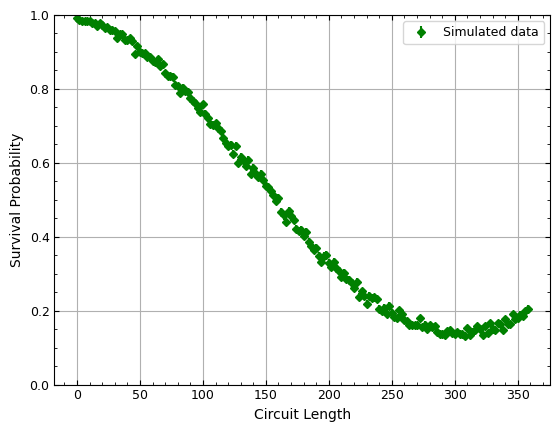

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% QSQBenchmarkResult %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

============================== Short Sequnce Results =============================
robust_soundness_lb_fidelity = 0.96672192, 
robust_state_prep_quality = 0.97950000, 
robust_measurement_quality = 0.02050000, 
--------------- Old numerical indicators:, 
numerical_lb_fidelity = 0.98783333, 
state_preparation_quality = 0.90875000, 
measurement_quality = 0.96958333, 
============================= Additional Information =============================
averaged error probability for depths [0,2,4] = 0.01216667 +/- 0.00141468, 
εₖ map = 0: 0.02050000, 1: 0.02850000, 2: 0.03150000, 3: 0.03200000, ...
summed confidence for depths [0,2,4] = 0.69880579, 
individual confidences = 0: 0.32967995, 2: 0.32967995, 4: 0.32967995
backend = NoisyAerSimulator, 


In [5]:
# Process the data and obtain performance indicators
data = QSQPostProcessing(
    sequencer_data = results,
    simulation=True, 
    save=False
    )

print(data.results)

## Sequence of random noisy $R_y(\frac{\pi}{2})$ gates 

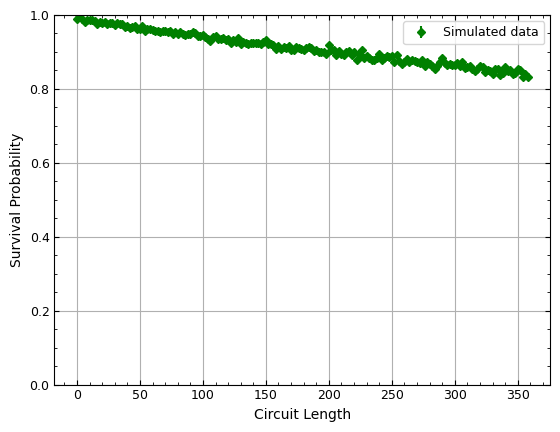

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% QSQBenchmarkResult %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

============================== Short Sequnce Results =============================
robust_soundness_lb_fidelity = 0.97626315, 
robust_state_prep_quality = 0.98350000, 
robust_measurement_quality = 0.01650000, 
--------------- Old numerical indicators:, 
numerical_lb_fidelity = 0.99050000, 
state_preparation_quality = 0.92875000, 
measurement_quality = 0.97625000, 
============================= Additional Information =============================
averaged error probability for depths [0,2,4] = 0.00950000 +/- 0.00125197, 
εₖ map = 0: 0.01650000, 1: 0.01850000, 2: 0.03000000, 3: 0.03050000, ...
summed confidence for depths [0,2,4] = 0.69880579, 
individual confidences = 0: 0.32967995, 2: 0.32967995, 4: 0.32967995
backend = NoisyAerSimulator, 


In [6]:
# This QuantumCircuit child class samples random unitaries at the gate level 
# (not at shot level), and composes the gates with them to create noisy channels.
# U → U · exp(-i p H) with probability p, and H being sampled from SU(2)
# check class to understand implementation
nqc = UnitaryNoisyQuantumCircuit(
    1, 
    error_probability=0.1, 
    max_offset= np.pi/15,
    )

data = sequencer.run_circuits( # Reuses backend from before, but replaces circuit
    depths = depths, 
    shots = 1000, 
    gate = "ry", 
    theta = np.pi/2,
    qubit = 0, # qubit register to apply sequencing

    qc = nqc, # Overwrite circuit for noisy
)

qsq = QSQPostProcessing(data)
print(qsq.results)

## Sequence of $R_z(\frac{\pi}{2})$ 

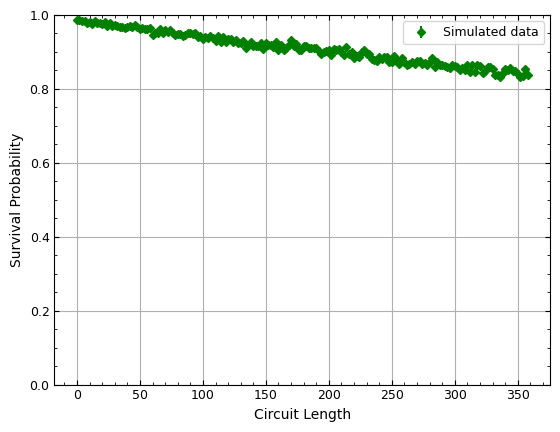

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% QSQBenchmarkResult %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

============================== Short Sequnce Results =============================
robust_soundness_lb_fidelity = 0.96226862, 
robust_state_prep_quality = 0.97300000, 
robust_measurement_quality = 0.02700000, 
--------------- Old numerical indicators:, 
numerical_lb_fidelity = 0.98583333, 
state_preparation_quality = 0.89375000, 
measurement_quality = 0.96458333, 
============================= Additional Information =============================
averaged error probability for depths [0,2,4] = 0.01416667 +/- 0.00152558, 
εₖ map = 0: 0.02700000, 1: 0.02800000, 2: 0.03300000, 3: 0.03850000, ...
summed confidence for depths [0,2,4] = 0.69880579, 
individual confidences = 0: 0.32967995, 2: 0.32967995, 4: 0.32967995
backend = NoisyAerSimulator, 


In [7]:
qc = QuantumCircuit(1)

# prepare state in 1/sqrt(2)(|0> - i|1>)
qc.rx(np.pi/2, 0)

data = sequencer.run_circuits(
    depths = depths, 
    shots = 1000, 
    gate = "rz", 
    phi = np.pi/2,
    measurement_basis = "Y",

    qc = qc, # overwrite quantum circuit
)

qsq = QSQPostProcessing(data)
print(qsq.results)